# Spherical Distribution Functions

galpy includes several distribution functions for spherical systems, both
isotropic and anisotropic. These DFs are tied to a specific spherical potential
and can be used to compute properties of the system or to generate samples.

Available spherical DFs include:

- **isotropicHernquistdf**: isotropic DF for a Hernquist potential
- **isotropicNFWdf**: isotropic DF for an NFW potential
- **isotropicPlummerdf**: isotropic DF for a Plummer potential
- **kingdf**: King model DF
- **constantbetaHernquistdf**: constant velocity-anisotropy Hernquist DF
- **osipkovmerrittHernquistdf**: Osipkov-Merritt anisotropic Hernquist DF

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## Isotropic Hernquist DF

The `isotropicHernquistdf` is initialized from a `HernquistPotential` instance.
The DF is a function of energy only, $f(E)$, corresponding to an isotropic
velocity distribution.

In [2]:
from galpy.potential import HernquistPotential
from galpy.df import isotropicHernquistdf

hp = HernquistPotential(amp=2.0, a=1.3)
dfh = isotropicHernquistdf(pot=hp)

### Evaluating the DF as a function of energy

The DF can be evaluated at a given (relative) energy $E$. The relative energy
is defined as $E = \Psi(r) - \frac{1}{2}v^2$ where $\Psi = -\Phi$ is the
relative potential:

Text(0.5, 1.0, 'Isotropic Hernquist DF')

/home/bovy/miniforge3/envs/py313/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)



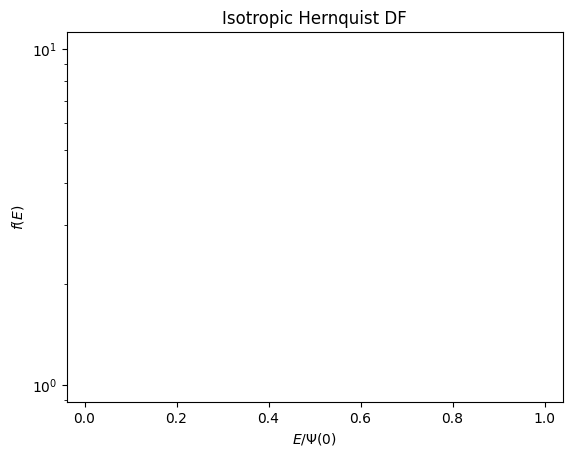

In [3]:
# Evaluate at several energies
Es = numpy.linspace(0.01, 0.99, 50)
# Scale by Psi(0) to get the DF as a function of relative energy
from galpy.potential import evaluatePotentials

psi0 = -evaluatePotentials(hp, 0.0, 0.0, use_physical=False)
fE = numpy.array([dfh.fE(E * psi0) for E in Es])
plt.semilogy(Es, fE)
plt.xlabel(r"$E / \Psi(0)$")
plt.ylabel(r"$f(E)$")
plt.title("Isotropic Hernquist DF")

### Sampling positions and velocities

The `sample` method draws random phase-space points from the DF.
By default it returns an `Orbit` object:

In [4]:
samples = dfh.sample(n=1000)
print("Type:", type(samples))
print("Number of orbits:", len(samples))

Type: <class 'galpy.orbit.Orbits.Orbit'>
Number of orbits: 1000


Let's plot the spatial distribution of the sampled orbits:

(-15.0, 15.0)

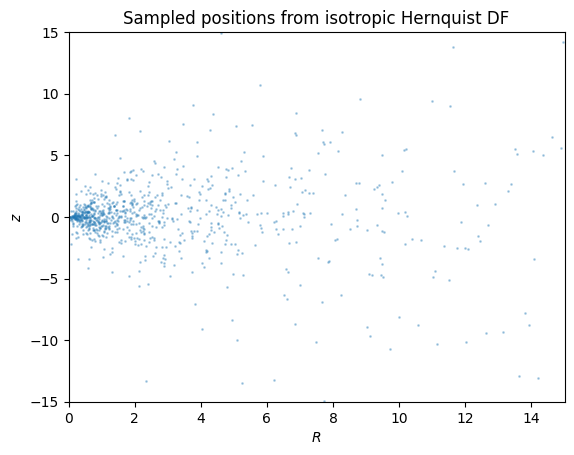

In [5]:
# Plot the spatial distribution
Rs = numpy.sqrt(samples.x() ** 2 + samples.y() ** 2)
zs = samples.z()
plt.scatter(Rs, zs, s=1, alpha=0.3)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Sampled positions from isotropic Hernquist DF")
plt.xlim(0, 15)
plt.ylim(-15, 15)

### Velocity dispersion profile

We can compare the velocity dispersion profile of the samples to the
analytical prediction. The `sigmar` method computes $\sigma_r(r)$:

Text(0.5, 1.0, 'Velocity dispersion profile')

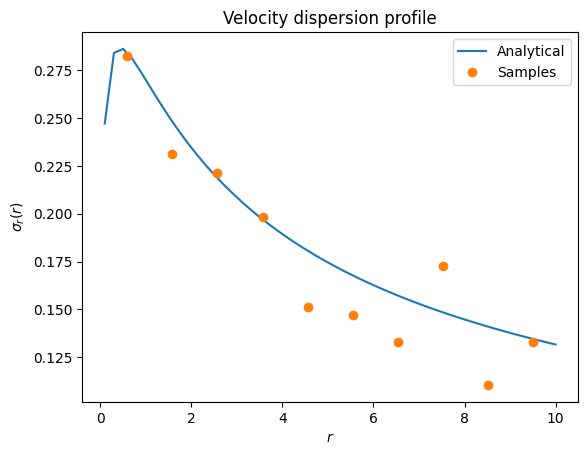

In [6]:
# Analytical velocity dispersion
rs = numpy.linspace(0.1, 10.0, 50)
sigmar = numpy.array([dfh.sigmar(r) for r in rs])

# Velocity dispersion from samples
r_samples = numpy.sqrt(samples.x() ** 2 + samples.y() ** 2 + samples.z() ** 2)
vr_samples = (
    samples.x() * samples.vx() + samples.y() * samples.vy() + samples.z() * samples.vz()
) / r_samples

# Bin the samples
rbins = numpy.linspace(0.1, 10.0, 11)
rmid = 0.5 * (rbins[:-1] + rbins[1:])
sig_binned = numpy.zeros(len(rmid))
for i in range(len(rmid)):
    mask = (r_samples >= rbins[i]) & (r_samples < rbins[i + 1])
    if numpy.sum(mask) > 2:
        sig_binned[i] = numpy.std(vr_samples[mask])

plt.plot(rs, sigmar, label="Analytical")
plt.plot(rmid, sig_binned, "o", label="Samples")
plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r(r)$")
plt.legend()
plt.title("Velocity dispersion profile")

## King DF

The King DF models a tidally-truncated, lowered-isothermal distribution.
It is initialized with the dimensionless central potential $W_0$, total mass, and
tidal radius:

Text(0.5, 1.0, 'King model radial distribution (W0=3)')

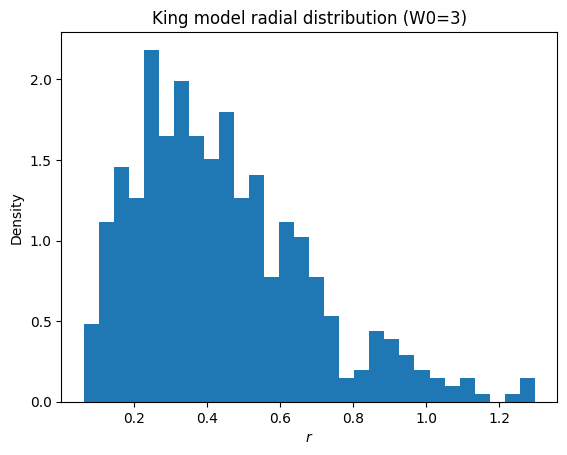

In [7]:
from galpy.df import kingdf

kdf = kingdf(W0=3.0, M=1.0, rt=1.5)

# Sample from the King model
king_samples = kdf.sample(n=500)
r_king = numpy.sqrt(
    king_samples.x() ** 2 + king_samples.y() ** 2 + king_samples.z() ** 2
)
plt.hist(r_king, bins=30, density=True)
plt.xlabel(r"$r$")
plt.ylabel("Density")
plt.title("King model radial distribution (W0=3)")

## Anisotropic DFs

galpy includes anisotropic DFs for spherical systems. The `constantbetaHernquistdf`
has a constant velocity anisotropy parameter $\beta$, while
`osipkovmerrittHernquistdf` has radially-varying anisotropy controlled by a
characteristic radius $r_a$.

### Constant-beta Hernquist DF

In [8]:
from galpy.df import constantbetaHernquistdf

hp = HernquistPotential(amp=2.0, a=1.3)
dfb = constantbetaHernquistdf(pot=hp, beta=0.3)

# Sample and check anisotropy
samples_b = dfb.sample(n=2000)
print("Number of samples:", len(samples_b))

Number of samples: 2000


### Osipkov-Merritt Hernquist DF

The Osipkov-Merritt DF has $\beta(r) = r^2/(r^2 + r_a^2)$, transitioning
from isotropic at the center to radially anisotropic at large radii:

Text(0.5, 1.0, 'Comparing isotropic and anisotropic Hernquist DFs')

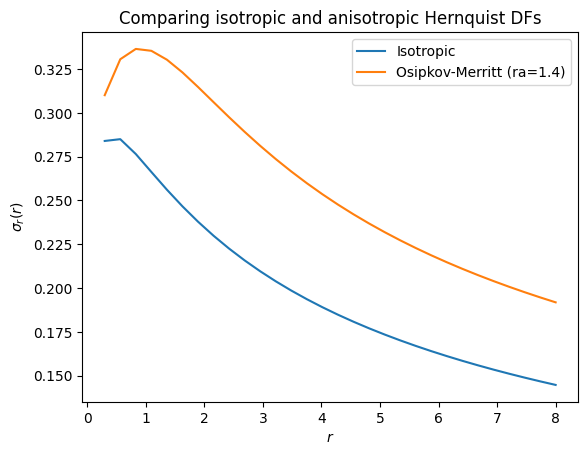

In [9]:
from galpy.df import osipkovmerrittHernquistdf

dfom = osipkovmerrittHernquistdf(pot=hp, ra=1.4)

# Compare velocity dispersion profiles
rs = numpy.linspace(0.3, 8.0, 30)
sig_iso = numpy.array([dfh.sigmar(r) for r in rs])
sig_om = numpy.array([dfom.sigmar(r) for r in rs])

plt.plot(rs, sig_iso, label="Isotropic")
plt.plot(rs, sig_om, label="Osipkov-Merritt (ra=1.4)")
plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r(r)$")
plt.legend()
plt.title("Comparing isotropic and anisotropic Hernquist DFs")